In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras
%matplotlib inline

In [2]:
df = pd.read_csv("insurance_data.csv")
df.head()

,age,affordibility,bought_insurance
0,22,1,0
1,25,0,0
2,47,1,1
3,52,0,0
4,46,1,1


In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df[['age', 'affordibility']], df.bought_insurance, test_size=0.2, random_state=42
)

In [4]:
len(X_train), len(X_test), len(y_train), len(y_test)

(22, 6, 22, 6)

In [5]:
X_train_scale = X_train.copy()
X_train_scale['age'] = X_train_scale['age'] / 100
X_test_scale = X_test.copy()
X_test_scale['age'] = X_test_scale['age'] / 100

In [6]:
X_train.shape, y_train.shape

((22, 2), (22,))

In [13]:
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Flatten(),
    keras.layers.Dense(1, activation='sigmoid', kernel_initializer='ones', bias_initializer='zeros')
])
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train_scale, y_train, epochs=5000)

Epoch 1/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step - accuracy: 0.5000 - loss: 0.7428
Epoch 2/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.7424
Epoch 3/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5000 - loss: 0.7420
Epoch 4/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 0.7416
Epoch 5/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5000 - loss: 0.7411
Epoch 6/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.5000 - loss: 0.7407
Epoch 7/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5000 - loss: 0.7403
Epoch 8/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.5000 - loss: 0.7399
Epoch 9/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 0.7395
Epoch 10/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 0.7390
Epoch 11/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5000 - loss: 0.7386
Epoch 12/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy

In [14]:
model.evaluate(X_test_scale, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 1.0000 - loss: 0.2647


[0.26470300555229187, 1.0]

In [15]:
y_predict = model.predict(X_test_scale)
y_predict[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


array([0.81626713], dtype=float32)

In [16]:
y_predict = [1 if i > 0.5 else 0 for i in y_predict]

In [19]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predict)
cm

<tf.Tensor: shape=(2, 2), dtype=int32, numpy=
array([[3, 0],
       [0, 3]], dtype=int32)>

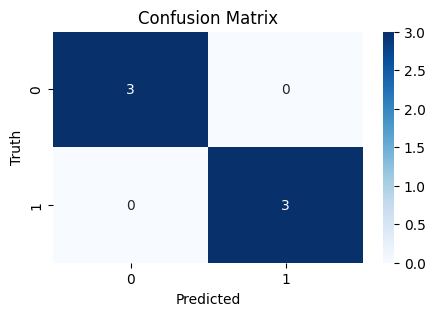

In [22]:
import seaborn as sns
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
plt.show()

In [24]:
coeff, intercept = model.get_weights()
print(f"Coefficient: {coeff}, Intercept: {intercept}")

Coefficient: [[5.0183096]
 [1.1966311]], Intercept: [-2.7665412]


In [28]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def log_loss(y_true, y_predicted):
    if np.any(y_predicted == 0) or np.any(y_predicted == 1):
        return -np.mean(y_true * np.log(np.clip(y_predicted, 1e-15, 1 - 1e-15)) + (1-y_true) * np.log(np.clip(1-y_predicted, 1e-15, 1 - 1e-15)))
    else:
        return -np.mean(y_true * np.log(y_predicted) + (1-y_true) * np.log(1-y_predicted))


def gradient_descent(age, affordibility, y_true, epochs, loss_threshold):
    w1 = w2 = 1
    bias = 0
    learning_rate = 0.1
    n = len(age)

    for i in range(epochs):
        weighted_sum = w1*age + w2*affordibility + bias
        y_predicted = sigmoid(weighted_sum)
        loss = log_loss(y_true, y_predicted)

        dw1 = np.mean(np.dot(np.transpose(age), (y_predicted - y_true)))
        dw2 = np.mean(np.dot(np.transpose(affordibility), (y_predicted - y_true)))
        dbias = np.mean(y_predicted - y_true)

        w1 -= learning_rate * dw1
        w2 -= learning_rate * dw2
        bias -= learning_rate * dbias

        print(f"Epoch {i+1}: w1={w1}, w2={w2}, bias={bias}, loss:{loss}")
        
        if loss < loss_threshold:
            print(f"Stopping at epoch {i+1} as loss {loss} is below threshold {loss_threshold}")
            break

    return w1, w2, bias

In [29]:
gradient_descent(X_train_scale['age'], X_train_scale['affordibility'], y_train, epochs=5000, loss_threshold=0.4923)

Epoch 1: w1=0.8842357002928037, w2=0.6981107683016998, bias=-0.023497903333540897, loss:0.7428288579142563
Epoch 2: w1=0.812054649028825, w2=0.49425822343789017, bias=-0.04202607459582548, loss:0.6979686476112493
Epoch 3: w1=0.7738307912874093, w2=0.3674400315307359, bias=-0.056698710684002826, loss:0.6776832940229774
Epoch 4: w1=0.7584235496524786, w2=0.2925974018409636, bias=-0.06878224062040264, loss:0.6694257409425176
Epoch 5: w1=0.7570526560393688, w2=0.24984440464899207, bias=-0.07926723075949357, loss:0.6660002275703399
Epoch 6: w1=0.7639113328032183, w2=0.22600374495442035, bias=-0.08880634238179766, loss:0.6643046055701158
Epoch 7: w1=0.7754661316628391, w2=0.21305078978655742, bias=-0.09779598167121342, loss:0.6631927185320093
Epoch 8: w1=0.7896522409569957, w2=0.20629331591160938, bias=-0.10646759797286855, loss:0.662273240003523
Epoch 9: w1=0.8052875335855771, w2=0.2030425886417622, bias=-0.11495367249522236, loss:0.6614177947812631
Epoch 10: w1=0.8217025942101243, w2=0.201

(np.float64(5.536682446221355),
 np.float64(0.7983474178989256),
 np.float64(-2.5679142238742827))